### 1. Imports

In [3]:
from __future__ import annotations
import os
import random
from dataclasses import dataclass
from typing import Dict, Any, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import tensorflow as tf

# Sionna imports (required)
try:
    import sionna
    from sionna.phy.mapping import Constellation, Mapper, Demapper
    from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
except Exception as e:
    raise ImportError("Please install sionna (and its dependencies). Import error: " + str(e))

### 2. Globals, hyperparameters, devices

In [4]:
@dataclass(frozen=True)
class SimConfig:
    # Dataset size
    num_examples: int = 10_000

    # Modulation
    seq_length: int = 128
    bits_per_symbol: int = 4

    # LDPC (5G)
    k: int = 256

    # Pilots (SC)
    pilot_len: int = 8
    pilot_bits_per_symbol: int = 2
    pilot_seed: int = 999

    # Channel: Eb/N0 range (info-bit)
    ebn0_db_min: float = 0.0
    ebn0_db_max: float = 12.0

    # Impairments ranges
    phase_min: float = -np.pi
    phase_max: float = np.pi

    # CFO configuration (cycles/symbol)
    cfo_mode: str = "direct"
    cfo_norm_min: float = -2e-4
    cfo_norm_max: float = +2e-4
    cfo_eps_min: float = -0.05
    cfo_eps_max: float = +0.05

    # Receiver blocks
    demap_method: str = "app"
    dec_num_iter: int = 15
    cn_update: str = "minsum"

    # Reproducibility
    seed: int = 46
    seed_noise: Optional[int] = None
    llr_noise_scaling: float = 1.0

    # Waveform
    waveform: str = "sc"

    # Eb/N0 overhead flags
    include_pilot_overhead_in_no: bool = True

    # Format / tf dtypes
    channels_last: bool = True
    tf_rdtype: tf.dtypes.DType = tf.float32
    tf_cdtype: tf.dtypes.DType = tf.complex64

### 3. Utils and helpers

In [5]:
def set_seed_all(seed: int = 46):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        from sionna.phy import config as sn_config
        sn_config.seed = int(seed)
    except Exception:
        pass

def expj(theta: tf.Tensor, cdtype: tf.DType) -> tf.Tensor:
    return tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)

def complex_to_2ch_real(x: tf.Tensor, channels_last: bool) -> tf.Tensor:
    i = tf.math.real(x)
    q = tf.math.imag(x)
    return tf.stack([i, q], axis=-1 if channels_last else -2)

def awgn_manual_with_seed(x: tf.Tensor, no: tf.Tensor, seed: int, rdtype: tf.DType, cdtype: tf.DType) -> tf.Tensor:
    rng = tf.random.Generator.from_seed(int(seed))
    std = tf.sqrt(no / tf.constant(2.0, rdtype))
    nr = rng.normal(tf.shape(x), dtype=rdtype) * std
    ni = rng.normal(tf.shape(x), dtype=rdtype) * std
    w = tf.complex(nr, ni)
    return tf.cast(x, cdtype) + tf.cast(w, cdtype)

# -------------------------
# Sionna blocks builder
# -------------------------
def build_sionna_blocks(cfg: SimConfig):
    m = int(cfg.bits_per_symbol)
    constellation = Constellation("qam", num_bits_per_symbol=m)
    mapper = Mapper(constellation=constellation)
    demapper = Demapper(cfg.demap_method, constellation=constellation)

    n = int(cfg.seq_length) * m
    encoder = LDPC5GEncoder(k=int(cfg.k), n=int(n), num_bits_per_symbol=m)
    decoder = LDPC5GDecoder(
        encoder=encoder,
        num_iter=int(cfg.dec_num_iter),
        return_infobits=True,
        hard_out=True,
        cn_update=str(cfg.cn_update),
    )
    return constellation, mapper, demapper, encoder, decoder

# -------------------------
# Deterministic pilot generator
# -------------------------
def make_deterministic_symbols_tf(cfg: SimConfig, N: int, num_symbols: int, bits_per_symbol: int, seed: int):
    rng = tf.random.Generator.from_seed(int(seed))
    bits = rng.uniform([num_symbols * bits_per_symbol], minval=0, maxval=2, dtype=tf.int32)
    const = Constellation("qam", num_bits_per_symbol=int(bits_per_symbol))
    mapper = Mapper(constellation=const)
    x1 = tf.cast(mapper(tf.reshape(bits, [1, num_symbols * bits_per_symbol])), cfg.tf_cdtype)
    x = tf.tile(x1, [N, 1])
    return {"bits": bits, "x": x}

# -------------------------
# SC TX + Channel simulation (vectorized TF)
# -------------------------
def simulate_full_frames_sc_tf(cfg: SimConfig) -> Dict[str, Any]:
    """
    Single-carrier frame:
      x_tx = [pilots(P), data(L)]  -> total T = P+L symbols
      y[t] = x_tx[t] * exp(j*(phi0 + 2*pi*cfo_norm*t)) + w[t]
    """
    set_seed_all(cfg.seed)
    rng = tf.random.Generator.from_seed(int(cfg.seed))

    N = int(cfg.num_examples)
    L = int(cfg.seq_length)
    m = int(cfg.bits_per_symbol)
    P = int(cfg.pilot_len)
    T = P + L
    n = L * m
    k = int(cfg.k)

    if not (0 < k < n):
        raise ValueError(f"Invalid k={k}. Must satisfy 0 < k < n={n} (n=L*m).")
    R = float(k) / float(n)

    # Sionna blocks
    _, mapper, _, encoder, _ = build_sionna_blocks(cfg)

    # Pilots (deterministic)
    pilot_pack = make_deterministic_symbols_tf(cfg, N=N, num_symbols=P, bits_per_symbol=int(cfg.pilot_bits_per_symbol), seed=int(cfg.pilot_seed))
    pilot_bits = pilot_pack["bits"]
    x_pilot = pilot_pack["x"]  # [N,P] complex

    # Info bits + LDPC encode
    info_bits = rng.uniform([N, k], minval=0, maxval=2, dtype=tf.int32)
    coded_bits_f = encoder(tf.cast(info_bits, cfg.tf_rdtype))  # [N,n] floats {0,1}
    coded_bits = tf.cast(coded_bits_f, tf.int32)

    # Map coded bits -> QAM symbols
    x_data = tf.cast(mapper(coded_bits), cfg.tf_cdtype)  # [N,L]
    x_tx = tf.concat([x_pilot, x_data], axis=1)  # [N,T]

    # Impairments
    phi0 = rng.uniform([N, 1], minval=cfg.phase_min, maxval=cfg.phase_max, dtype=cfg.tf_rdtype)  # [N,1]
    cfo = rng.uniform([N, 1], minval=cfg.cfo_norm_min, maxval=cfg.cfo_norm_max, dtype=cfg.tf_rdtype)  # cycles/symbol
    t = tf.range(T, dtype=cfg.tf_rdtype)[None, :]  # [1,T]
    phi_total = phi0 + tf.constant(2.0 * np.pi, cfg.tf_rdtype) * cfo * t  # [N,T]
    x_tx_phase = x_tx * expj(phi_total, cfg.tf_cdtype)

    # Eb/N0 -> noise variance
    ebn0_db = rng.uniform([N], minval=cfg.ebn0_db_min, maxval=cfg.ebn0_db_max, dtype=cfg.tf_rdtype)  # [N]
    ebn0_lin = tf.pow(tf.constant(10.0, cfg.tf_rdtype), ebn0_db / 10.0)

    overhead_val = 1.0
    if cfg.include_pilot_overhead_in_no:
        overhead_val *= (P + L) / float(L)
    overhead = tf.constant(overhead_val, dtype=cfg.tf_rdtype)

    es = tf.reduce_mean(tf.abs(x_tx_phase) ** 2, axis=1, keepdims=True)  # [N,1]
    no = es / (tf.reshape(ebn0_lin, [-1, 1]) * (m * R)) * overhead  # [N,1]

    noise_seed = cfg.seed if cfg.seed_noise is None else int(cfg.seed_noise)
    y_rx = awgn_manual_with_seed(x_tx_phase, no, seed=noise_seed, rdtype=cfg.tf_rdtype, cdtype=cfg.tf_cdtype)

    meta = {
        "waveform": "sc",
        "N": int(N), "L": int(L), "P": int(P), "T": int(T),
        "m": int(m), "k": int(k), "n": int(n), "R": float(R),
        "seed": int(cfg.seed),
        "pilot_bits_per_symbol": int(cfg.pilot_bits_per_symbol),
    }

    return {
        "info_bits": info_bits,            # tf int32
        "coded_bits": coded_bits,          # tf int32
        "pilot_bits": pilot_bits,          # tf int32
        "x_pilot": x_pilot,                # tf complex [N,P]
        "x_data": x_data,                  # tf complex [N,L]
        "x_tx": x_tx,                      # tf complex [N,T]
        "y_rx": y_rx,                      # tf complex [N,T]
        "phi0": phi0,                      # tf float [N,1]
        "cfo_norm": cfo,                   # tf float [N,1]
        "ebn0_db": ebn0_db,                # tf float [N]
        "no": no,                          # tf float [N,1]
        "meta": meta
    }

### 4. Data loading

In [6]:
def generate_dataset_offline(cfg: SimConfig) -> Dict[str, Any]:
    full = simulate_full_frames_sc_tf(cfg)

    P_meta = int(full["meta"]["P"])
    T_meta = int(full["meta"]["T"])

    # Full-frame IQ (time-domain)
    tx_iq_full = complex_to_2ch_real(full["x_tx"], cfg.channels_last).numpy().astype(np.float32)  # [N,T,2]
    rx_iq_full = complex_to_2ch_real(full["y_rx"], cfg.channels_last).numpy().astype(np.float32)

    # Split into pilot/data in time-domain
    P_time = P_meta
    D_time = T_meta - P_time

    if cfg.channels_last:
        tx_iq_pilot_time = tx_iq_full[:, :P_time, :]
        rx_iq_pilot_time = rx_iq_full[:, :P_time, :]
        tx_iq_data_time  = tx_iq_full[:, P_time:P_time + D_time, :]
        rx_iq_data_time  = rx_iq_full[:, P_time:P_time + D_time, :]
    else:
        tx_iq_pilot_time = tx_iq_full[:, :, :P_time]
        rx_iq_pilot_time = rx_iq_full[:, :, :P_time]
        tx_iq_data_time  = tx_iq_full[:, :, P_time:P_time + D_time]
        rx_iq_data_time  = rx_iq_full[:, :, P_time:P_time + D_time]

    ds: Dict[str, Any] = {
        "info_bits": full["info_bits"].numpy().astype(np.uint8),
        "coded_bits": full["coded_bits"].numpy().astype(np.uint8),
        "pilot_bits": full["pilot_bits"].numpy().astype(np.uint8),
        "tx_iq_full_time": tx_iq_full,
        "rx_iq_full_time": rx_iq_full,
        "tx_iq_pilot_time": tx_iq_pilot_time,
        "rx_iq_pilot_time": rx_iq_pilot_time,
        "tx_iq_data_time": tx_iq_data_time,
        "rx_iq_data_time": rx_iq_data_time,
        "phi0": full["phi0"].numpy().astype(np.float32),
        "cfo_norm": full["cfo_norm"].numpy().astype(np.float32),
        "ebn0_db": full["ebn0_db"].numpy().astype(np.float32),
        "no": full["no"].numpy().astype(np.float32),
        "meta": full["meta"],
    }
    return ds

# -------------------------
# Classical receiver (SC)
# -------------------------
def estimate_phi_cfo_ml_grid_sc(cfg: SimConfig, y_pilot: tf.Tensor, x_pilot: tf.Tensor, cfo_min: float, cfo_max: float, grid_size: int = 129):
    rdtype = cfg.tf_rdtype
    cdtype = cfg.tf_cdtype
    P = tf.shape(y_pilot)[1]
    two_pi = tf.constant(2.0*np.pi, dtype=rdtype)
    eps_f = tf.constant(1e-9, dtype=rdtype)
    x_pow = tf.abs(x_pilot)**2
    r = y_pilot * tf.math.conj(x_pilot)
    r = r / tf.cast(x_pow + eps_f, cdtype)
    f_grid = tf.linspace(tf.constant(float(cfo_min), rdtype),
                         tf.constant(float(cfo_max), rdtype),
                         int(grid_size))
    p = tf.cast(tf.range(P)[None, :], rdtype)
    f = tf.reshape(f_grid, [-1, 1])
    theta = -two_pi * f * p
    E = tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)
    z = tf.einsum("np,mp->nm", r, E)
    mags = tf.abs(z)
    idx = tf.argmax(mags, axis=1, output_type=tf.int32)
    cfo_hat = tf.gather(f_grid, idx)[:, None]
    z_best = tf.gather(z, idx, axis=1, batch_dims=1)[:, None]
    phi_hat = tf.cast(tf.math.angle(z_best), rdtype)
    denom = tf.reduce_sum(tf.abs(r), axis=1, keepdims=True) + eps_f
    conf = tf.abs(z_best) / denom
    return phi_hat, cfo_hat, conf

def classical_receiver_sc(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    _, _, demapper, _, decoder = build_sionna_blocks(cfg)
    meta = full["meta"]
    P = int(meta["P"])
    no = tf.cast(full["no"], cfg.tf_rdtype)
    y_rx = full["y_rx"]
    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
    info_bits  = tf.cast(full["info_bits"],  tf.uint8)
    y_pilot = y_rx[:, :P]
    x_pilot = full["x_pilot"]
    cfo_min = float(cfg.cfo_norm_min)
    cfo_max = float(cfg.cfo_norm_max)
    if P >= 2:
        phi_hat, cfo_hat, conf = estimate_phi_cfo_ml_grid_sc(cfg, y_pilot, x_pilot, cfo_min, cfo_max)
    else:
        z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot), axis=1, keepdims=True)
        phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype)
        cfo_hat = tf.zeros_like(phi_hat)
        conf = tf.ones_like(phi_hat)
    T = int(meta["T"])
    two_pi = tf.constant(2.0*np.pi, dtype=cfg.tf_rdtype)
    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)
    phi_total_hat = phi_hat + two_pi * cfo_hat * t
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)
    y_data = y_corr[:, P:]
    llr = tf.cast(demapper(tf.reshape(y_data, [tf.shape(y_data)[0], -1]), no), cfg.tf_rdtype)
    hard_coded = tf.cast(llr > 0.0, tf.uint8)
    info_hat_f = decoder(llr)
    info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)
    ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
    ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
    bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))
    return {"phi_hat": phi_hat, "cfo_hat": cfo_hat, "llr": llr, "info_bits_hat": info_hat, "metrics": {"ber_pre_coded": float(ber_pre.numpy()), "ber_post_info": float(ber_post.numpy()), "bler_post_info": float(bler_post.numpy())}}

# -------------------------
# DEVICE & dataloader builder
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

def get_pytorch_sc_loaders(base_cfg: SimConfig, batch_size: int = 128):
    print("Generating Specialized Dataset (80% in 4-8 dB range, 20% generalized)...")
    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})
    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)
    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0) # [N, L, 2]
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0) # [N, P, 2]
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0) # [N, L*m]
    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0) # [N, 1]
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0) # [N, 1]
    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    # correctly reshape coded bits: [N, n_bits] -> [N, m, L]
    m = base_cfg.bits_per_symbol
    L = base_cfg.seq_length
    target_bits_t = torch.tensor(target_bits).reshape(-1, L, m).permute(0, 2, 1).float()
    phi0_t = torch.tensor(phi0).float().squeeze()
    cfo_t = torch.tensor(cfo).float().squeeze()
    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t)
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)


Using Device: cuda


### 5. Model definition and architecture

In [7]:
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.dim_head = dim // heads
        self.scale = self.dim_head ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)
        self.gamma = nn.Linear(dim, dim)
        self.beta = nn.Linear(dim, dim)
    def forward(self, x, latent_z):
        style_scale = self.gamma(latent_z).unsqueeze(1)
        style_shift = self.beta(latent_z).unsqueeze(1)
        x = x * (1 + style_scale) + style_shift
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(b, n, self.heads, self.dim_head).transpose(1, 2), qkv)
        q = q.softmax(dim=-1) * self.scale
        k = k.softmax(dim=-2)
        context = torch.matmul(k.transpose(-1, -2), v)
        out = torch.matmul(q, context)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.to_out(out)

class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))

class HybridNeuralReceiver(nn.Module):
    def __init__(self, seq_len=128, n_pilots=8):
        super().__init__()
        in_dim = (2 * seq_len) + (2 * n_pilots)
        self.input_norm = nn.BatchNorm1d(in_dim)
        self.estimator = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 2)
        )
        self.latent_proj = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.Tanh())
        self.feat_extract = nn.Conv1d(2, 64, 7, padding=3)
        self.res1 = ResidualBlock1D(64)
        self.attn = LinearAttention(64)
        self.norm_attn = nn.LayerNorm(64)
        self.res2 = ResidualBlock1D(64)
        self.final_conv = nn.Conv1d(64, 32, 1)
        self.bit_head = nn.Conv1d(32, 4, 1)
    def forward(self, x, pilots, gt_phi=None, gt_cfo=None, mix_ratio=0.0):
        x_flat = x.reshape(x.size(0), -1)
        p_flat = pilots.reshape(pilots.size(0), -1)
        est_feats = self.input_norm(torch.cat([x_flat, p_flat], dim=1))
        est_params = self.estimator(est_feats)
        est_phi = est_params[:, 0]
        est_cfo = est_params[:, 1] / 1000.0
        if gt_phi is not None and mix_ratio < 1.0:
            phi = (1 - mix_ratio) * gt_phi + mix_ratio * est_phi
            cfo = (1 - mix_ratio) * gt_cfo + mix_ratio * est_cfo
        else:
            phi, cfo = est_phi, est_cfo
        z_input = torch.stack([torch.cos(phi), cfo * 1000.0], dim=1)
        z = self.latent_proj(z_input)
        B, _, L = x.shape
        t = torch.arange(L, device=x.device).float().unsqueeze(0)
        phase_ramp = phi.unsqueeze(1) + (cfo.unsqueeze(1) * t)
        cos_t, sin_t = torch.cos(-phase_ramp), torch.sin(-phase_ramp)
        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t
        x_derot = torch.stack([r_I, r_Q], dim=1)
        feat = F.relu(self.feat_extract(x_derot))
        feat = self.res1(feat)
        feat_attn = feat.permute(0, 2, 1)
        feat_attn = self.attn(self.norm_attn(feat_attn), z)
        feat = feat + feat_attn.permute(0, 2, 1)
        feat = self.res2(feat)
        logits = self.bit_head(F.relu(self.final_conv(feat)))
        return logits, est_phi, est_cfo

### 6. Model training and validation

In [8]:
cfg_sc = SimConfig(**{
    "num_examples": 3000,
    "bits_per_symbol": 4,
    "k": 256,
    "demap_method": "app",
    "dec_num_iter": 15,
    "cn_update": "minsum",
    "seed": 46,
    "channels_last": True,
    "cfo_mode": "direct",
    "cfo_norm_min": -2e-4,
    "cfo_norm_max": +2e-4,
    "ebn0_db_min": 0.0,
    "ebn0_db_max": 12.0,
    "pilot_bits_per_symbol": 2,
    "include_pilot_overhead_in_no": True,
    "waveform": "sc",
    "seq_length": 128,
    "pilot_len": 8,
})

# Build dataloaders
train_loader, val_loader = get_pytorch_sc_loaders(cfg_sc, batch_size=128)

# Model, optimizer, training loop
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridNeuralReceiver(seq_len=cfg_sc.seq_length, n_pilots=cfg_sc.pilot_len).to(DEVICE)
print(f"Total ML Parameters: {sum(p.numel() for p in model.parameters())}")

optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

print("\n--- Training ML Model on Single Carrier Waveform ---")
EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    metrics = {'loss':0.0, 'phi':0.0, 'cfo':0.0, 'ber':0.0}
    mix = min(1.0, epoch / (EPOCHS * 0.8))
    n_batches = 0
    for x, p, y_p, y_c, target_bits in train_loader:
        x, p, y_p, y_c, target_bits = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE), target_bits.to(DEVICE)
        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo = model(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)
        loss_bits = criterion_bce(bit_logits, target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss = loss_bits + 0.5 * loss_phi + 0.5 * loss_cfo
        loss.backward()
        optimizer.step()
        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        metrics['cfo'] += torch.abs(est_cfo - y_c).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()
        n_batches += 1
    scheduler.step()
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | Loss: {metrics['loss']/max(1,n_batches):.4f} | Phi MAE: {metrics['phi']/max(1,n_batches):.3f} | Train BER: {metrics['ber']/max(1,n_batches)*100:.2f}%")


Generating Specialized Dataset (80% in 4-8 dB range, 20% generalized)...
Total ML Parameters: 126598

--- Training ML Model on Single Carrier Waveform ---
Ep 01/15 | Mix: 0.00 | Loss: 0.9387 | Phi MAE: 0.735 | Train BER: 12.31%
Ep 02/15 | Mix: 0.08 | Loss: 0.5122 | Phi MAE: 0.435 | Train BER: 9.17%
Ep 03/15 | Mix: 0.17 | Loss: 0.4335 | Phi MAE: 0.363 | Train BER: 9.50%
Ep 04/15 | Mix: 0.25 | Loss: 0.3642 | Phi MAE: 0.307 | Train BER: 9.59%
Ep 05/15 | Mix: 0.33 | Loss: 0.3202 | Phi MAE: 0.273 | Train BER: 9.60%
Ep 06/15 | Mix: 0.42 | Loss: 0.2964 | Phi MAE: 0.235 | Train BER: 9.65%
Ep 07/15 | Mix: 0.50 | Loss: 0.2902 | Phi MAE: 0.224 | Train BER: 9.79%
Ep 08/15 | Mix: 0.58 | Loss: 0.2809 | Phi MAE: 0.205 | Train BER: 9.65%
Ep 09/15 | Mix: 0.67 | Loss: 0.2732 | Phi MAE: 0.197 | Train BER: 9.61%
Ep 10/15 | Mix: 0.75 | Loss: 0.2728 | Phi MAE: 0.191 | Train BER: 9.74%
Ep 11/15 | Mix: 0.83 | Loss: 0.2669 | Phi MAE: 0.184 | Train BER: 9.62%
Ep 12/15 | Mix: 0.92 | Loss: 0.2631 | Phi MAE: 0.172

### 7. Model evaluation and prints


--- Evaluating Baseline vs ML Model (Single Carrier) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2314 | ML BER: 0.2416
Eb/N0 = 02 dB | Classical Baseline BER: 0.1831 | ML BER: 0.1866
Eb/N0 = 04 dB | Classical Baseline BER: 0.1383 | ML BER: 0.1373
Eb/N0 = 06 dB | Classical Baseline BER: 0.0970 | ML BER: 0.0937
Eb/N0 = 08 dB | Classical Baseline BER: 0.0613 | ML BER: 0.0570
Eb/N0 = 10 dB | Classical Baseline BER: 0.0337 | ML BER: 0.0304
Eb/N0 = 12 dB | Classical Baseline BER: 0.0167 | ML BER: 0.0159


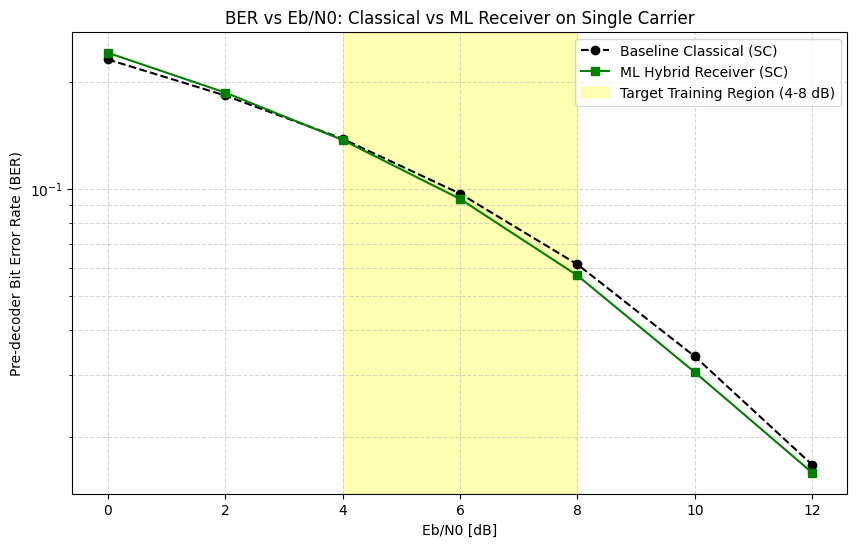

In [9]:
print("\n--- Evaluating Baseline vs ML Model (Single Carrier) ---")
ebn0_range = range(0, 13, 2)
ber_base, ber_ml = [], []

model.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_sc.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})
        # Classical baseline
        full_tf = simulate_full_frames_sc_tf(cfg_eval)
        rx_base = classical_receiver_sc(cfg_eval, full_tf)
        ber_base.append(rx_base["metrics"]["ber_pre_coded"])
        # ML eval
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0,2,1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0,2,1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_sc.seq_length, cfg_sc.bits_per_symbol).permute(0,2,1).float().to(DEVICE)
        bit_logits, _, _ = model(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml.append(ml_ber)
        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base[-1]:.4f} | ML BER: {ml_ber:.4f}")

# Plot results
plt.figure(figsize=(10,6))
plt.semilogy(list(ebn0_range), ber_base, 'k--o', label='Baseline Classical (SC)')
plt.semilogy(list(ebn0_range), ber_ml, 'g-s', label='ML Hybrid Receiver (SC)')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs ML Receiver on Single Carrier")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()